In [ ]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [3]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [4]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [5]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [ ]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})
Note:  
Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacities (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating and delayed behavior.
Please consider containing following structures in your expressions:
- Polynomial terms (e.g., x1², x2³)
- Exponential and logarithmic transformations
- Cross-variable interactions (e.g., x1 * x3, x2 / x4)
- Temporal modeling elements:
  - Moving average: movavg(x1, 3)
  - Residual dynamics: x1 - x2
  - State memory: x4, x5, (x4 - x5)

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in range [0, 1]. It is sensitive to bandwidth availability and processing load. Empirical observations show:
- When bandwidth is insufficient, task success sharply declines.
- When compute load nears saturation, task success drops abruptly.
- The y-value (success ratio) non-linearly changes with respect to x1–x3.
Please consider containing following structures in your expressions:
- Sigmoid-like structures to model saturating effects:  
  `y = 1 / (1 + exp(-...))`  
  `y = min(1, max(0, ...))`
- Load penalty: include inverse terms like `1 / (x3 + c)` or log-shifted forms like `log(x3 + 1)`
- Bandwidth interplay: try cross-variable interactions such as `x1 * x2` or `x1 / (x2 + 1)`
- Saturation indicators: consider residuals or thresholding functions for compute load
- Simpler alternatives: linear combinations, squares or square roots of x1/x2 if it captures the trend
- Avoid always returning expressions that collapse to ~0.5.
"""

Running experiment 1...
Give up equations whose nmae > 0.5: [{'equation': 'x2*x4-x5', 'complexity': 5, 'nmae': np.float64(0.7019800454665363), 'fitted_params': []}, {'equation': 'x1*x3+x4', 'complexity': 5, 'nmae': np.float64(82.09023265930257), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': 'log(1+x1)+x2', 'complexity': 6, 'nmae': np.float64(1.6310381333947923), 'fitted_params': []}, {'equation': '(x2-x3)**2+x1', 'complexity': 7, 'nmae': np.float64(14.231183777318947), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': 'min(1,max(0,x1*x2))', 'complexity': 3, 'nmae': np.float64(0.9652371564280537), 'fitted_params': []}, {'equation': 'x1/(x2+1)-log(x3+1)', 'complexity': 10, 'nmae': np.float64(1.5647373552317307), 'fitted_params': []}, {'equation': '1/(1+exp(-x1*x3))', 'complexity': 10, 'nmae': np.float64(2.776742521071798), 'fitted_params': []}]


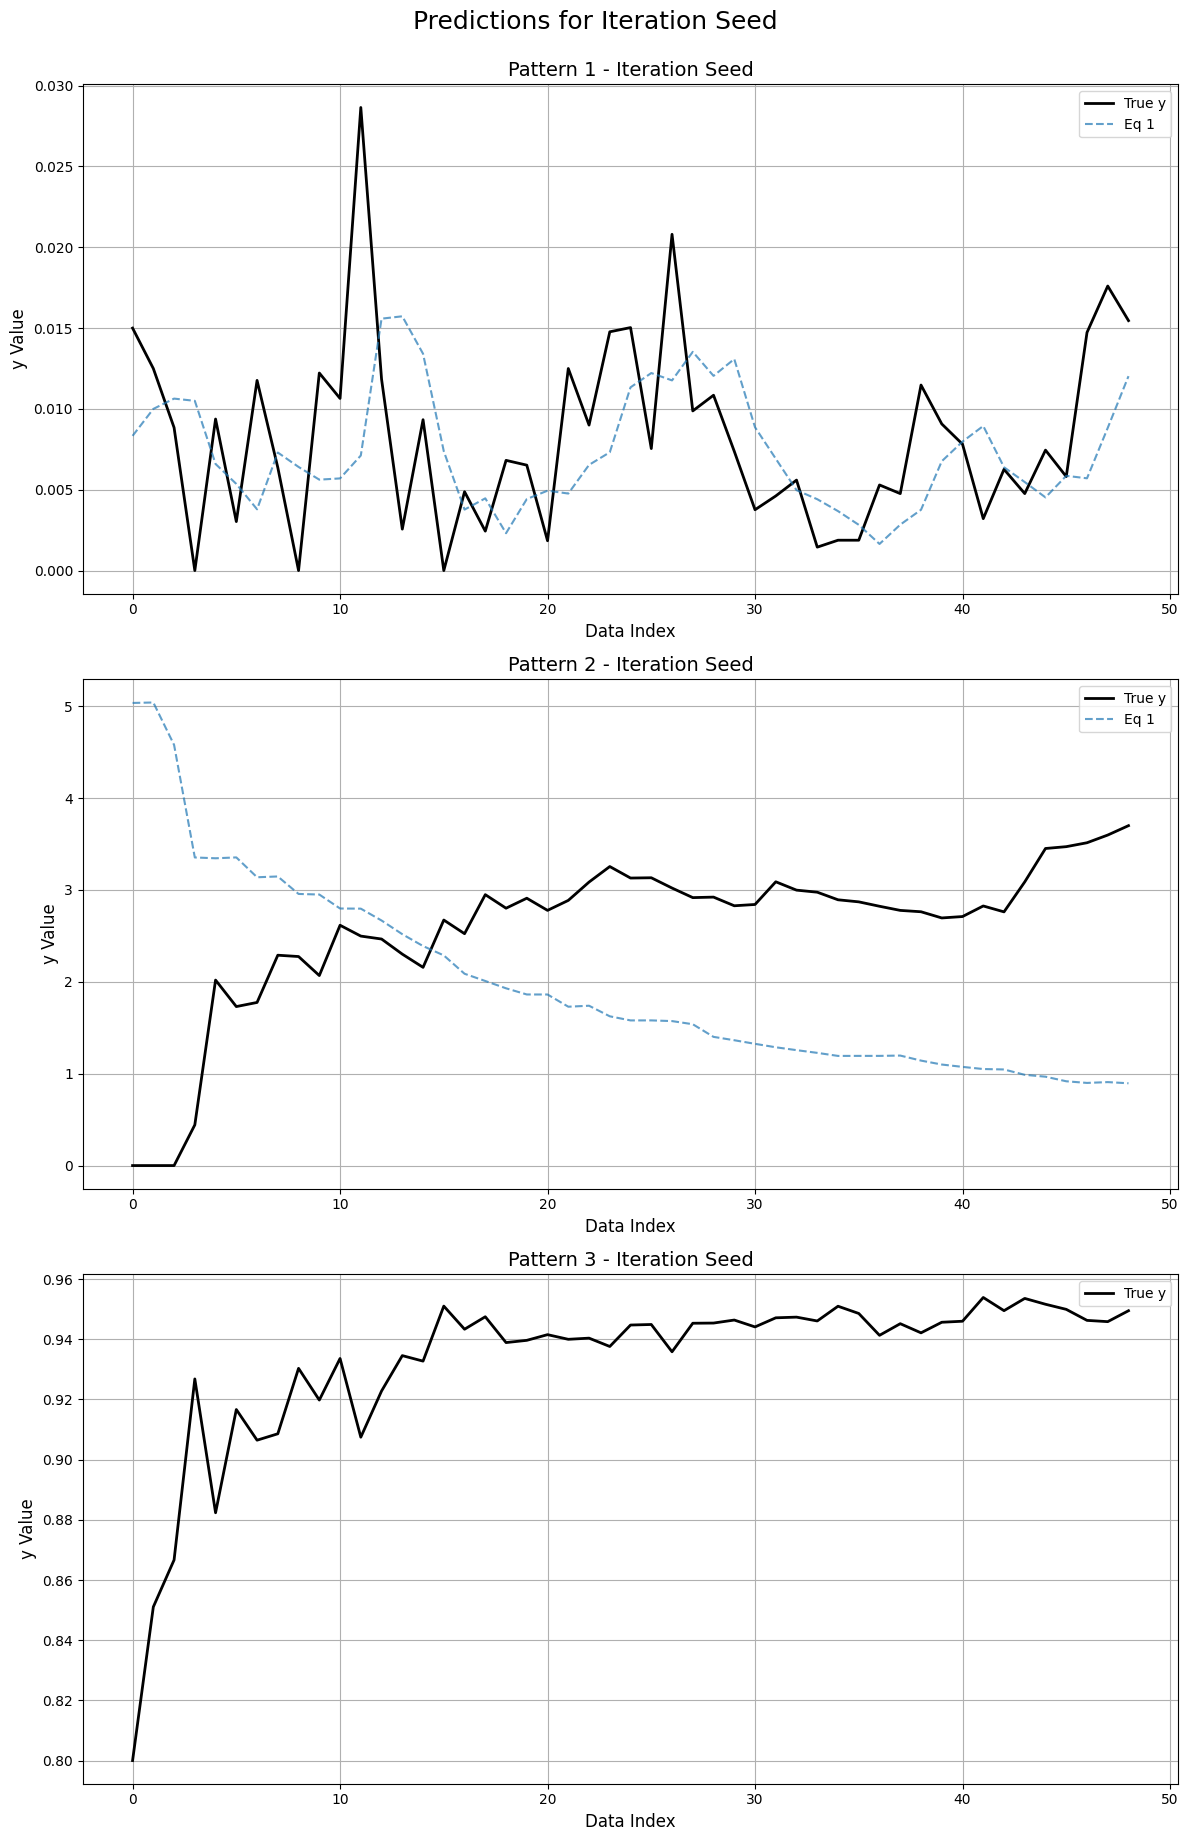

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1 Analysis:
- The dependent variable y shows complex oscillating behavior, potentially influenced by several factors.
- Polynomial terms, exponential/logarithmic transformations, cross-variable interactions, and temporal elements are suggested.
- Variables x1 and x3 seem to show a correlation with y, and temporal modeling with x4 and x5 is important for capturing state memory and residual dynamics.
- Expressions should consider polynomial terms like x1², x2³, exponential/logarithmic transformations, and moving averages.

Pattern 2 Analysis:
- The dependent variable y (average V2U rate) is influenced by vehicle density (x1), UAV density (x2), and compute load (x3).
- Saturating growth forms like x2/(1 + x1) are suggested due to the nature of V2U communication.
- Resource competition effects and mismatch capture using forms like (x2 - x3)² are recommended.
- Avoid bounding output strictly but 

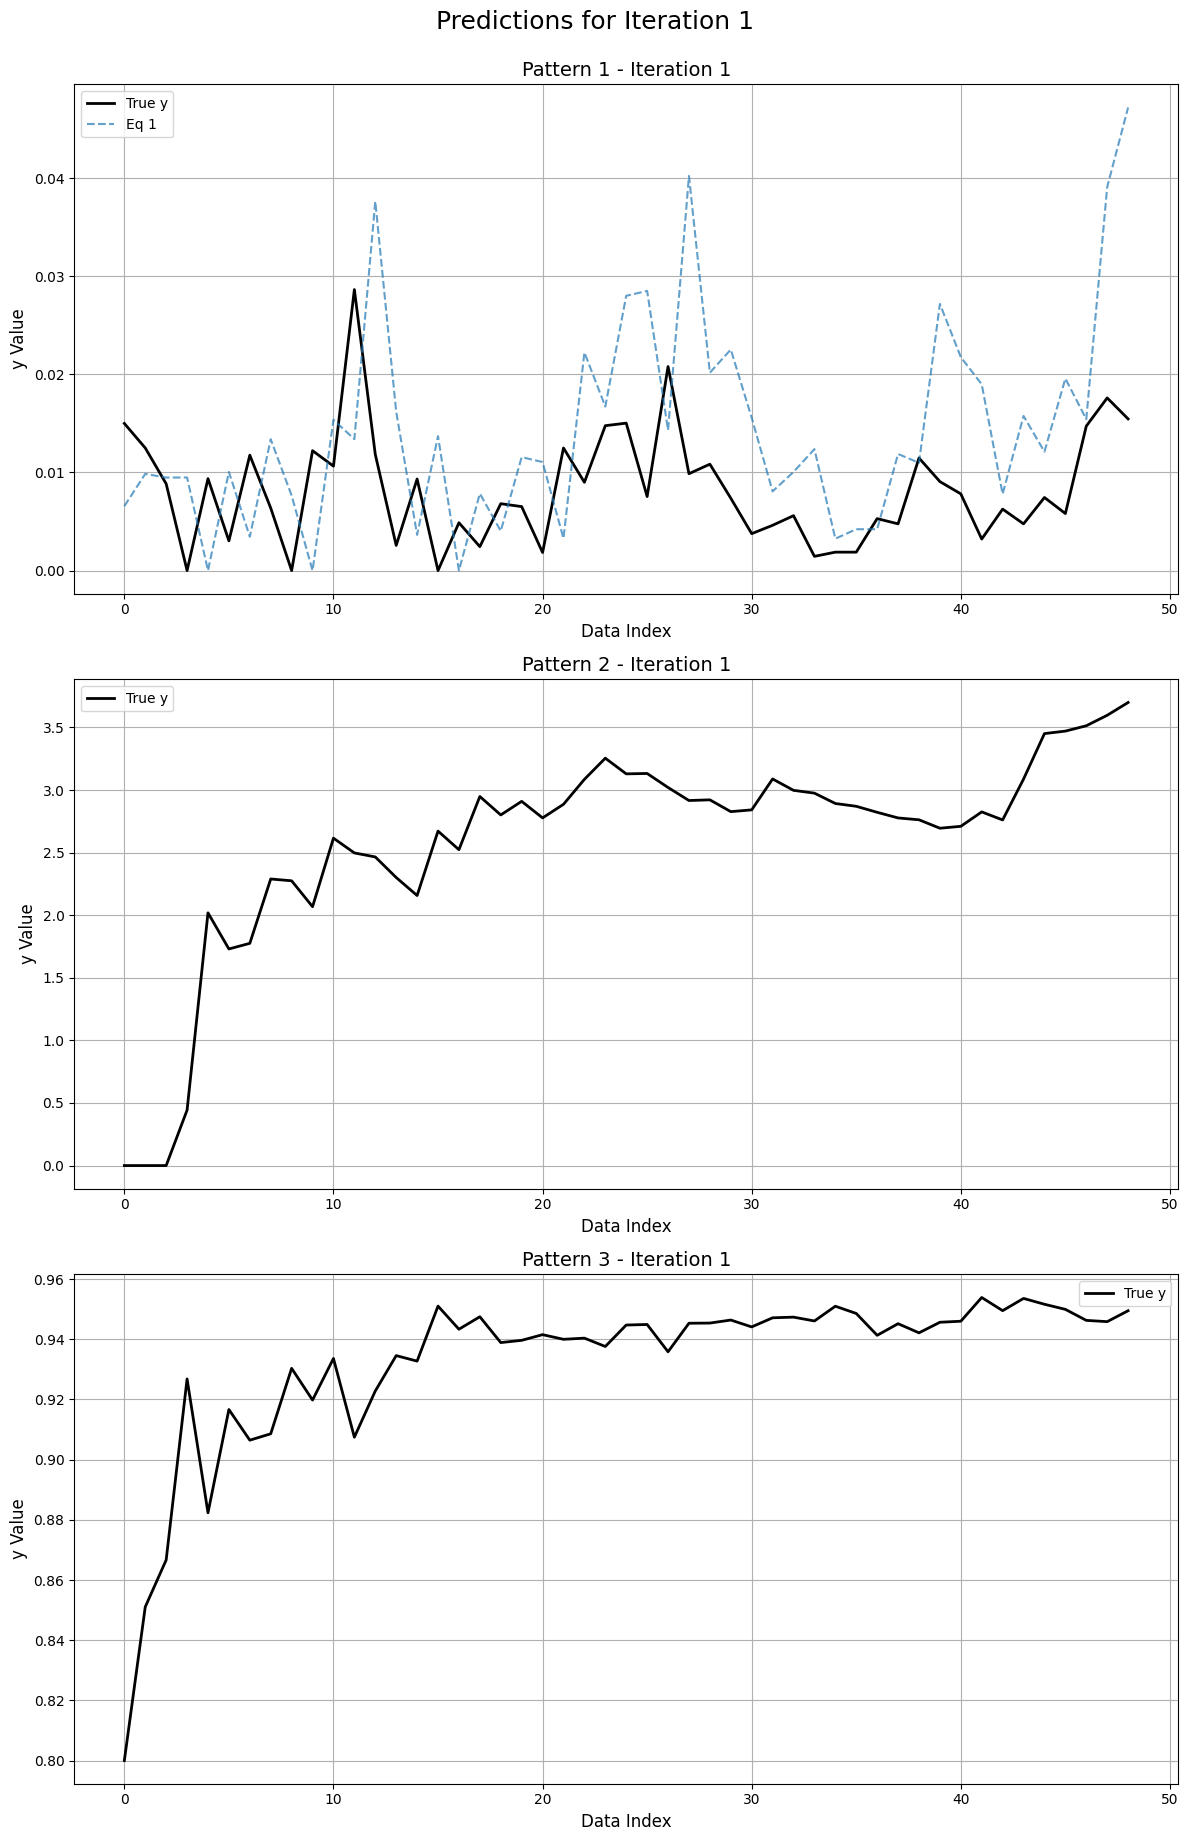

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'movavg(4, 3)*x1', 'complexity': 3, 'nmae': np.float64(0.1581889207483409), 'fitted_params': []}, {'equation': 'sqrt(x2)*x4', 'complexity': 4, 'nmae': np.float64(0.33800828577292497), 'fitted_params': []}], [{'equation': 'x2/(1+x1)+x3', 'complexity': 7, 'nmae': np.float64(0.4415651635517151), 'fitted_params': []}], []]
LLM thoughts:
Pattern 1 Analysis: 
The dependent variable y in Pattern 1 is the average compute load of the next time slot. It shows oscillating and delayed behavior, influenced by task arrival rate, CPU capacities, and traffic congestion. The complexity of the existing equation is low (3), with a relatively good fit (nmae = 0.158). We should explore polynomial terms, exponential/logarithmic transformations, cross-variable interactions, and temporal modeling elements.

Pattern 2 Analysis:
The dependent variable y in Pattern 2 is the average V2U rate of the next time slot. The current equation has a higher

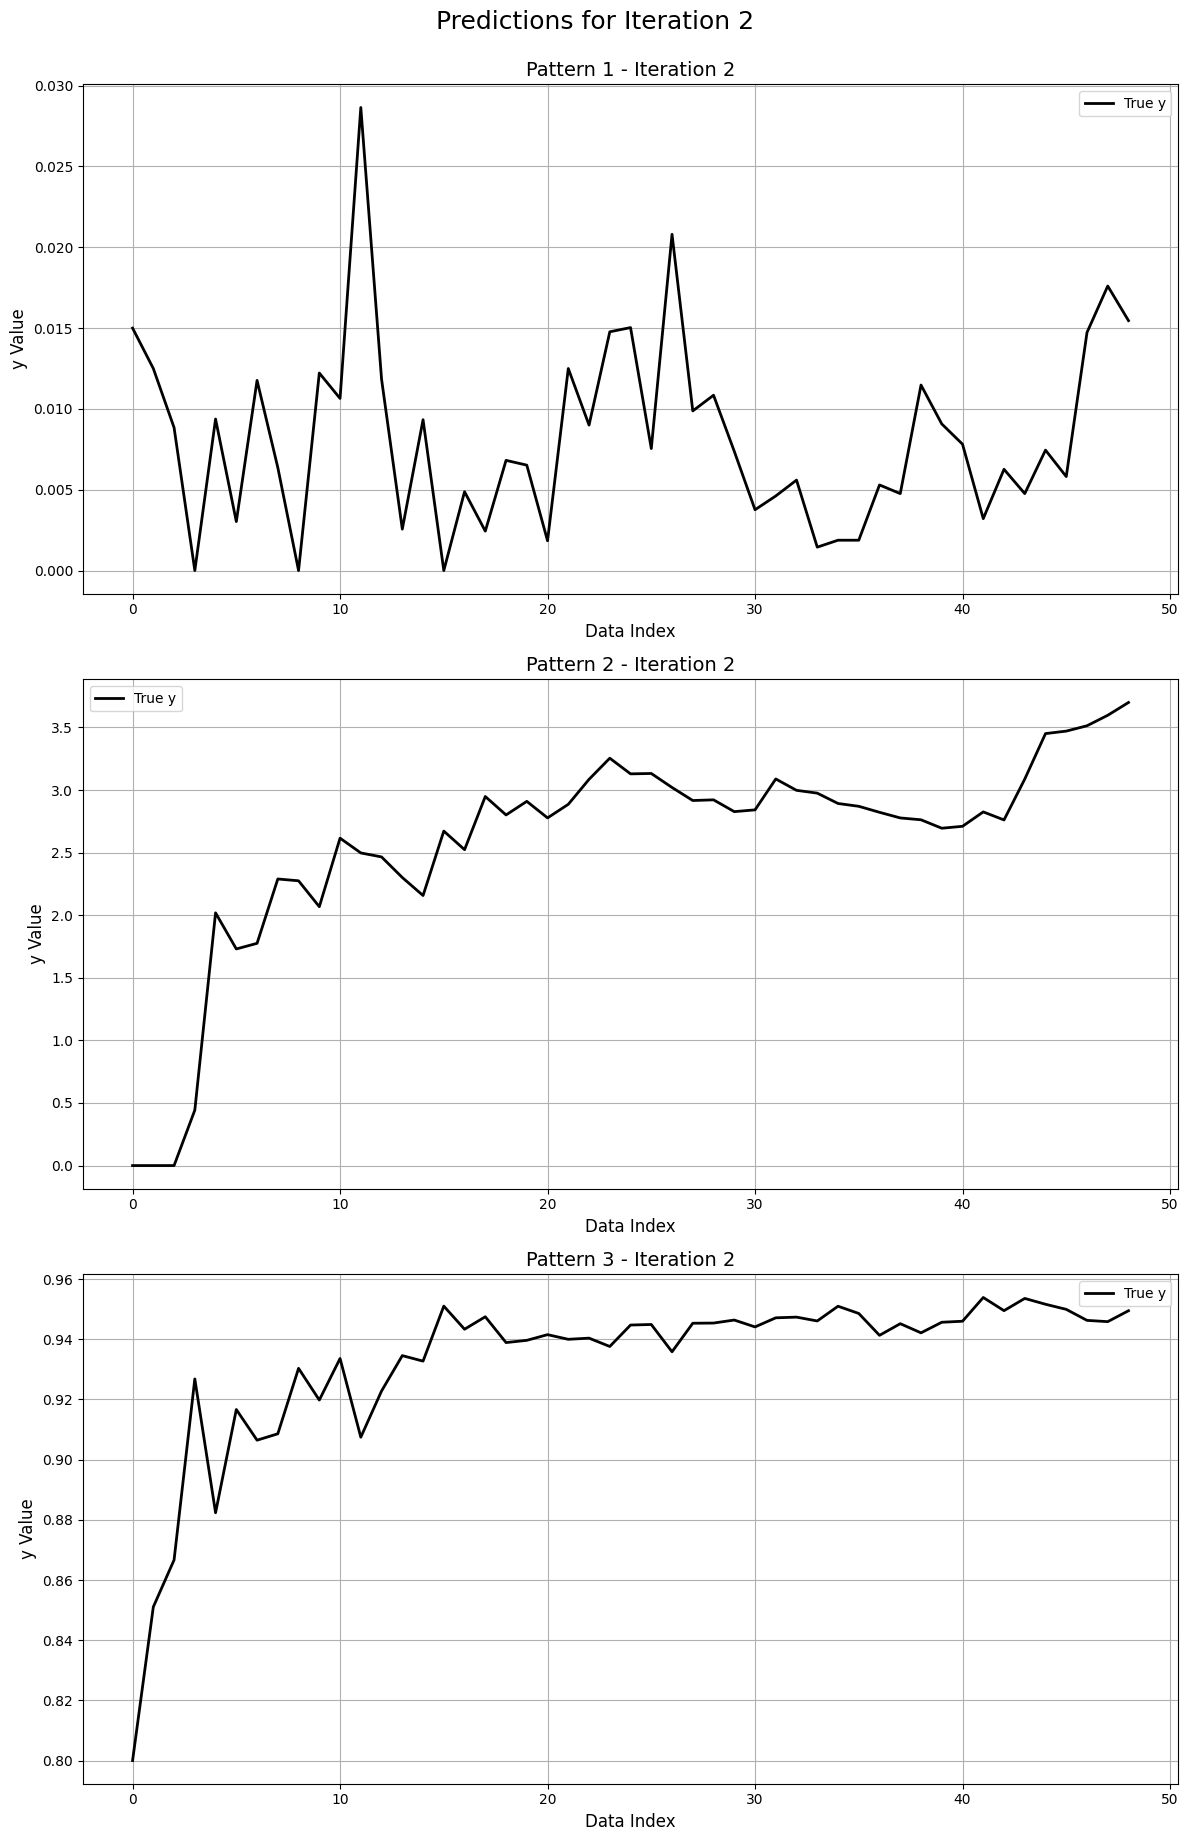

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'movavg(4, 3)*x1', 'complexity': 3, 'nmae': np.float64(0.1581889207483409), 'fitted_params': []}, {'equation': 'sqrt(x2)*x4', 'complexity': 4, 'nmae': np.float64(0.33800828577292497), 'fitted_params': []}], [{'equation': 'x2/(1+x1)+x3', 'complexity': 7, 'nmae': np.float64(0.4415651635517151), 'fitted_params': []}], []]
LLM thoughts:
First, let's analyze the dataset and the existing equations provided in the Pareto front. For each pattern, we'll consider the constraints and suggestions provided, aiming to generate diverse and concise expressions that minimize complexity and loss.

Pattern 1:
- The dependent variable is the average compute load at the next time slot.
- Encouraged structures include polynomial terms, exponential/logarithmic transformations, cross-variable interactions, and temporal modeling elements.
- The existing equations are relatively simple and incorporate moving average and square root transformatio

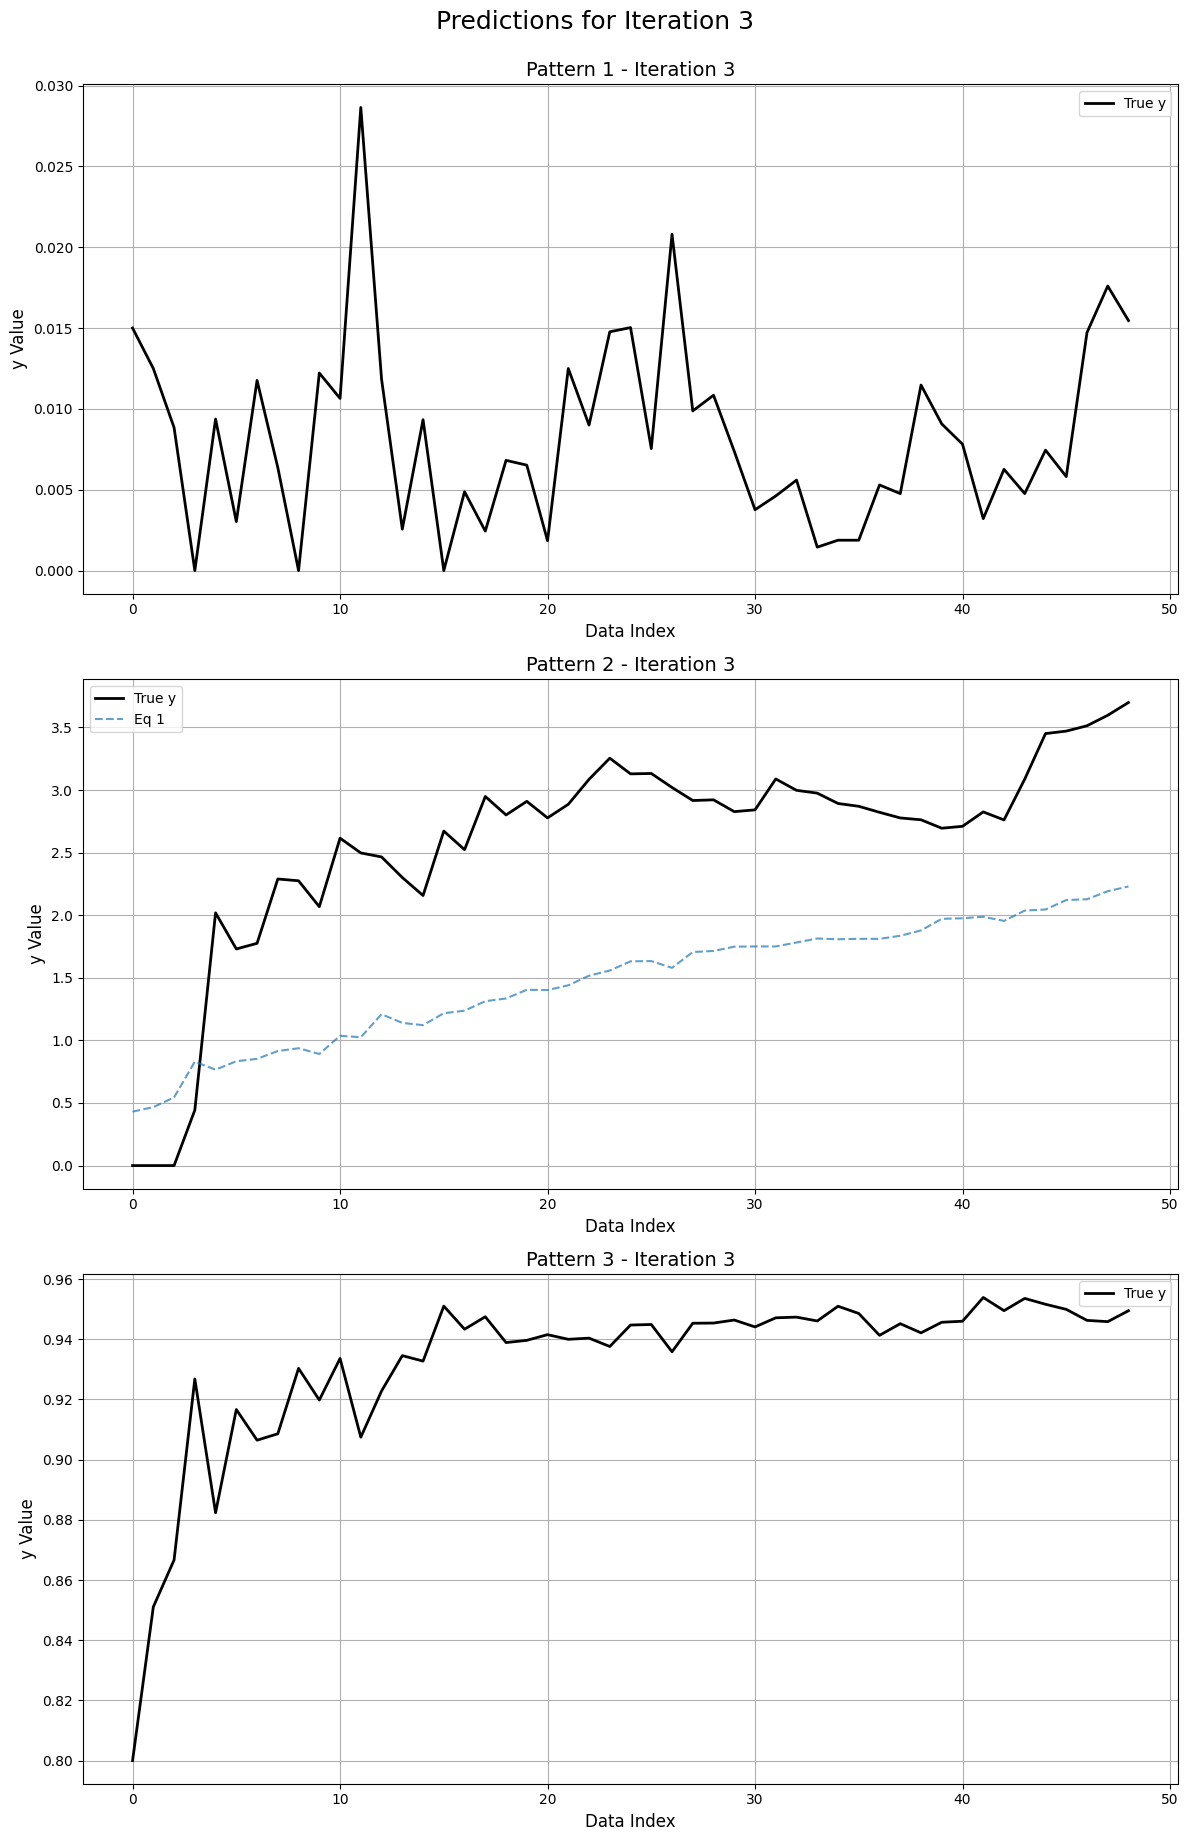

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'movavg(4, 3)*x1', 'complexity': 3, 'nmae': np.float64(0.1581889207483409), 'fitted_params': []}, {'equation': 'sqrt(x2)*x4', 'complexity': 4, 'nmae': np.float64(0.33800828577292497), 'fitted_params': []}], [{'equation': 'x2/(1+x1)+x3', 'complexity': 7, 'nmae': np.float64(0.4415651635517151), 'fitted_params': []}, {'equation': 'log(x1+1)+x2*x3', 'complexity': 8, 'nmae': np.float64(0.31784501652933955), 'fitted_params': []}], []]
LLM thoughts:
First Pattern Analysis:
1. The dependent variable, average compute load (y), shows complex oscillating and delayed behavior influenced by various factors such as task arrival rate, CPU capacities, and traffic congestion.
2. Polynomial terms, exponential and logarithmic transformations, cross-variable interactions, and temporal modeling elements are encouraged to capture this complexity.
3. The existing equation, `movavg(4, 3)*x1`, suggests the use of moving averages. Polynomial ter

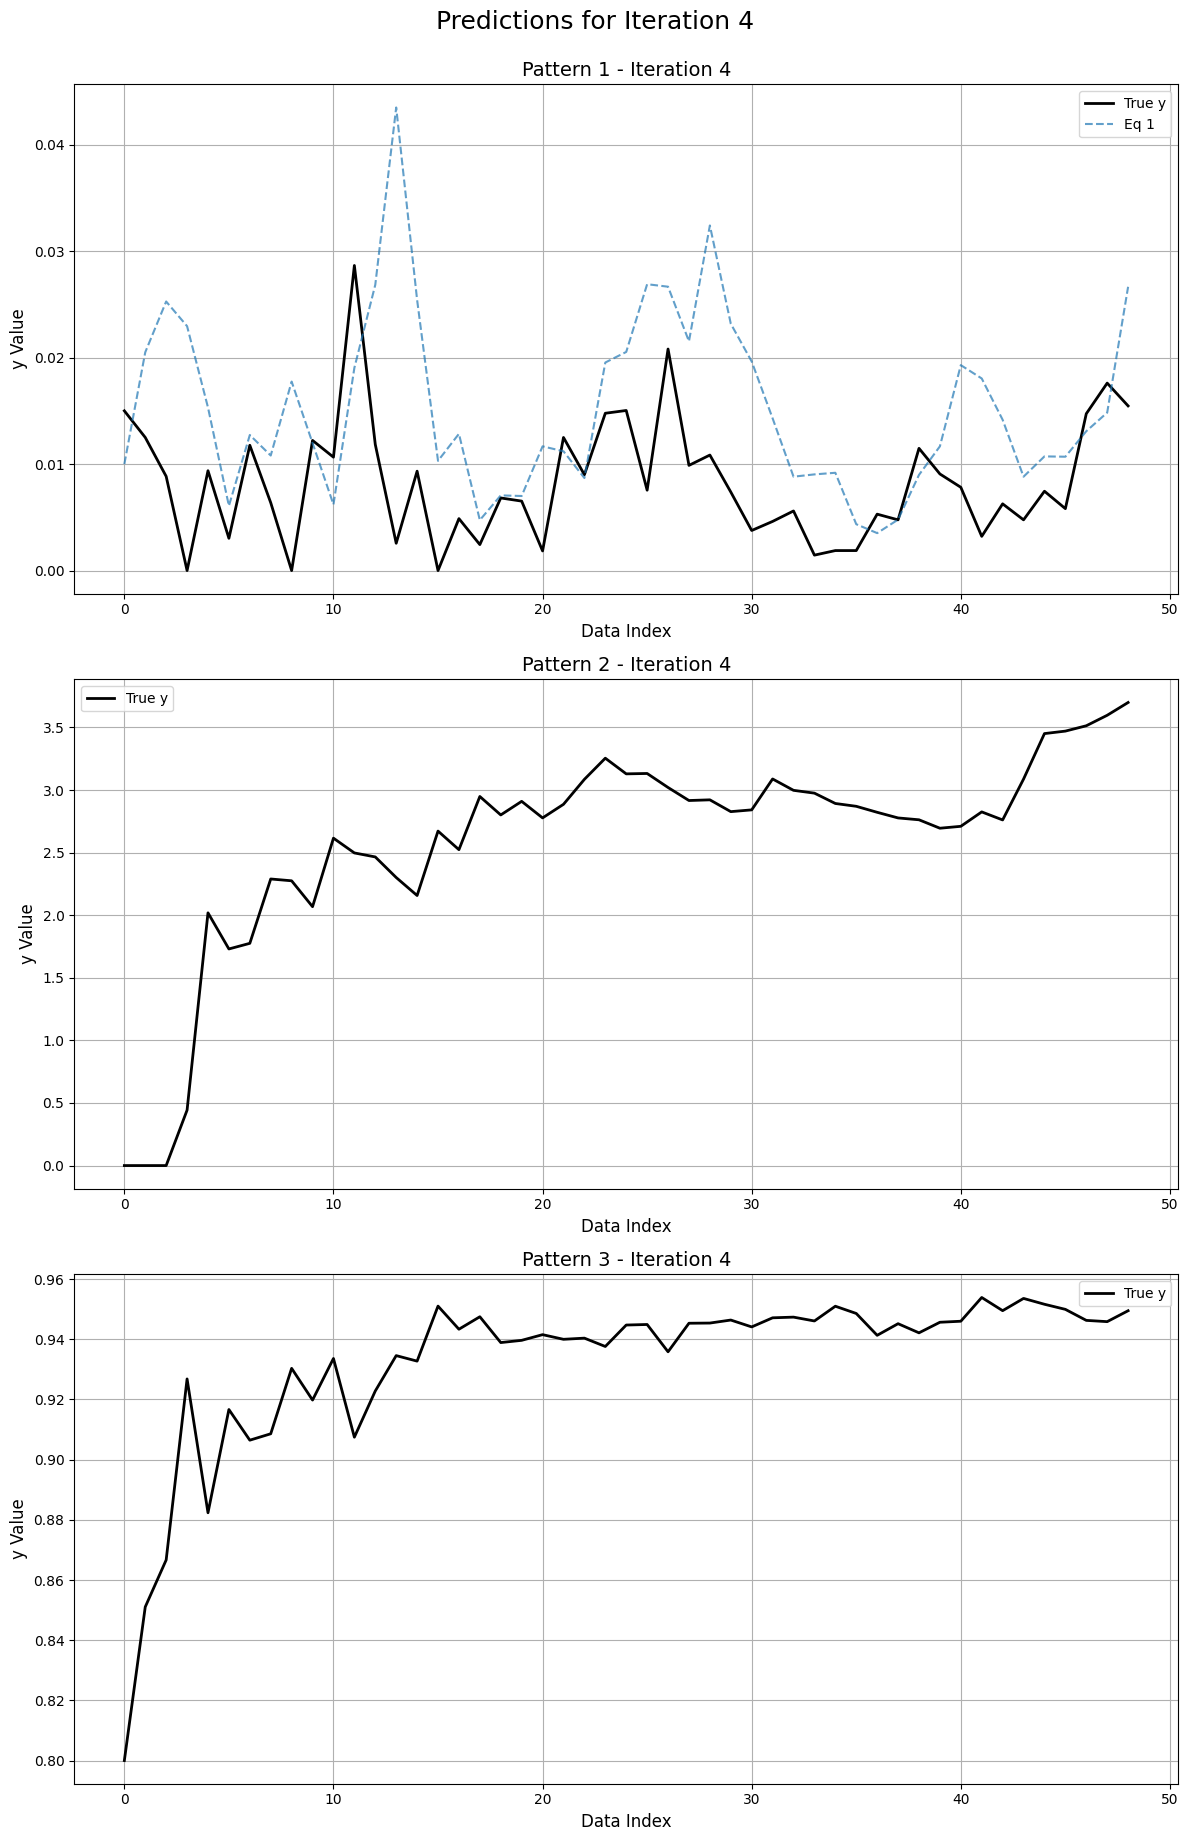

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'movavg(4, 3)*x1', 'complexity': 3, 'nmae': np.float64(0.1581889207483409), 'fitted_params': []}, {'equation': 'sqrt(x2)*x4', 'complexity': 4, 'nmae': np.float64(0.33800828577292497), 'fitted_params': []}, {'equation': 'movavg(4, 3)+x1*x5', 'complexity': 5, 'nmae': np.float64(0.2870778982531276), 'fitted_params': []}], [{'equation': 'x2/(1+x1)+x3', 'complexity': 7, 'nmae': np.float64(0.4415651635517151), 'fitted_params': []}, {'equation': 'log(x1+1)+x2*x3', 'complexity': 8, 'nmae': np.float64(0.31784501652933955), 'fitted_params': []}], []]
LLM thoughts:
Scratch Pad:

Pattern 1 Analysis:
- The dependent variable is influenced by past compute loads (x4, x5) and current indicators (x1, x2, x3).
- Suggest using polynomial terms with x1, x2, x3, and temporal elements (movavg, state memory).
- Consider interactions between variables for cross-effects.
- Avoid redundancy with previous suggestions.

Suggested expressions for P

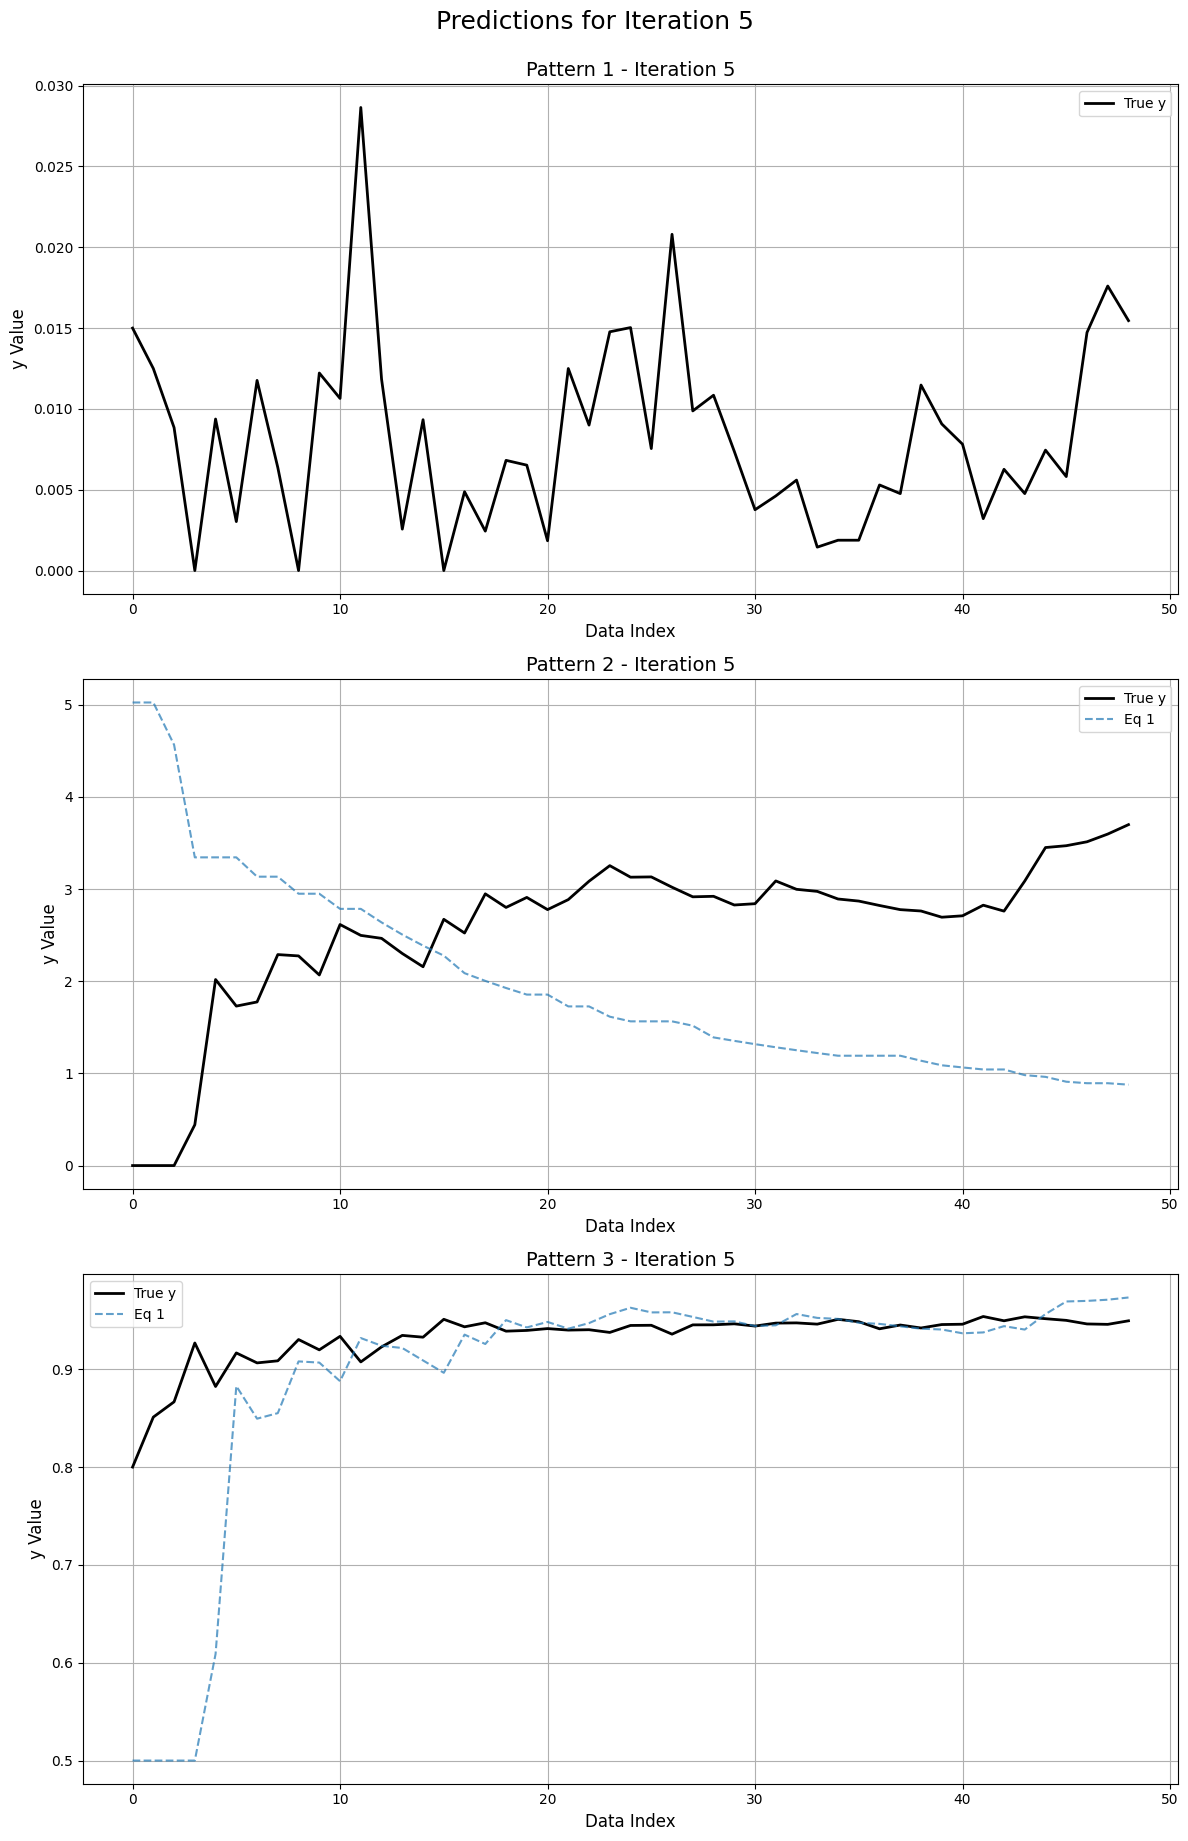

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'movavg(4, 3)*x1', 'complexity': 3, 'nmae': np.float64(0.1581889207483409), 'fitted_params': []}, {'equation': 'sqrt(x2)*x4', 'complexity': 4, 'nmae': np.float64(0.33800828577292497), 'fitted_params': []}, {'equation': 'movavg(4, 3)+x1*x5', 'complexity': 5, 'nmae': np.float64(0.2870778982531276), 'fitted_params': []}], [{'equation': 'x2/(1+x1)+x3', 'complexity': 7, 'nmae': np.float64(0.4415651635517151), 'fitted_params': []}, {'equation': 'log(x1+1)+x2*x3', 'complexity': 8, 'nmae': np.float64(0.31784501652933955), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
Pattern 1: The dependent variable shows complex oscillating and delayed behavior, influenced by the task arrival rate, CPU capacities, and traffic congestion. 

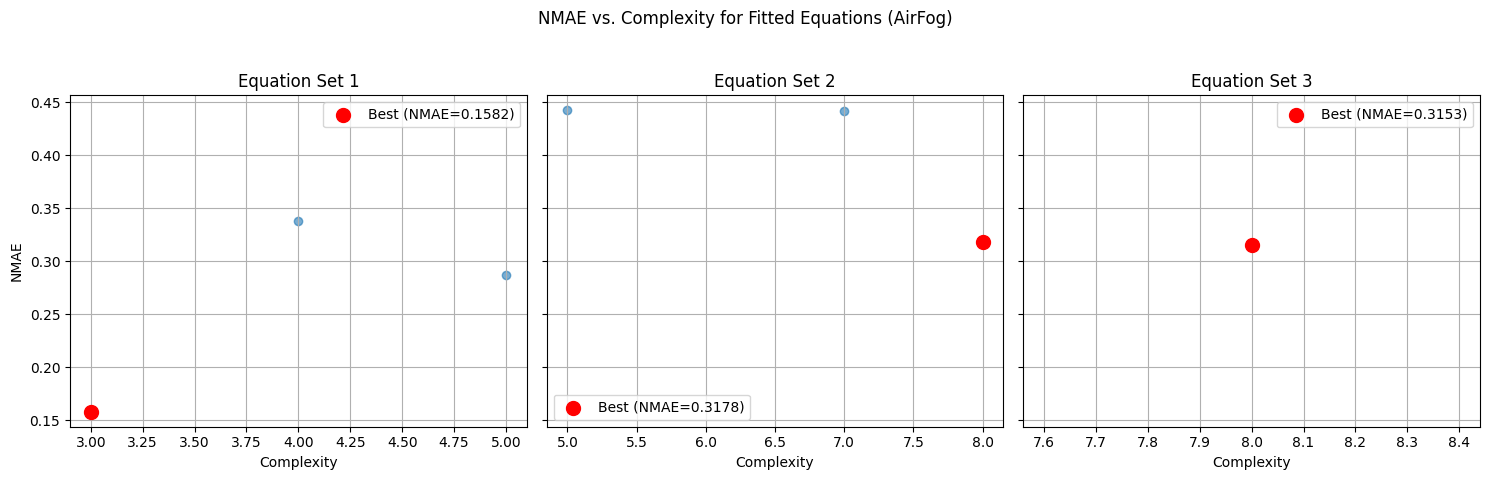

Experiment 1 finished.
Running experiment 2...
Give up equations whose nmae > 0.5: [{'equation': 'x1**2+x2*x3-movavg(4, 3)', 'complexity': 9, 'nmae': np.float64(388.7664952244765), 'fitted_params': []}, {'equation': 'x1*x3+exp(x3)-x5', 'complexity': 8, 'nmae': np.float64(631.8398143752353), 'fitted_params': []}, {'equation': 'x2**3/log(1+x3)+x4-x5', 'complexity': 12, 'nmae': np.float64(inf), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': '(x2-x3)**2-x1*x3', 'complexity': 9, 'nmae': np.float64(13.252828872667815), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': '1/(1+exp(-x1*x2+x3))', 'complexity': 12, 'nmae': np.float64(0.605856233630304), 'fitted_params': []}, {'equation': 'min(1,max(0,x1*x2/(x3+c[0])))', 'complexity': 7, 'nmae': np.float64(0.8067799798352965), 'fitted_params': [0.10811873619589375]}, {'equation': 'log(x3+1)/(x1+x2)+sqrt(x1)', 'complexity': 11, 'nmae': np.float64(inf), 'fitted_params': []}]


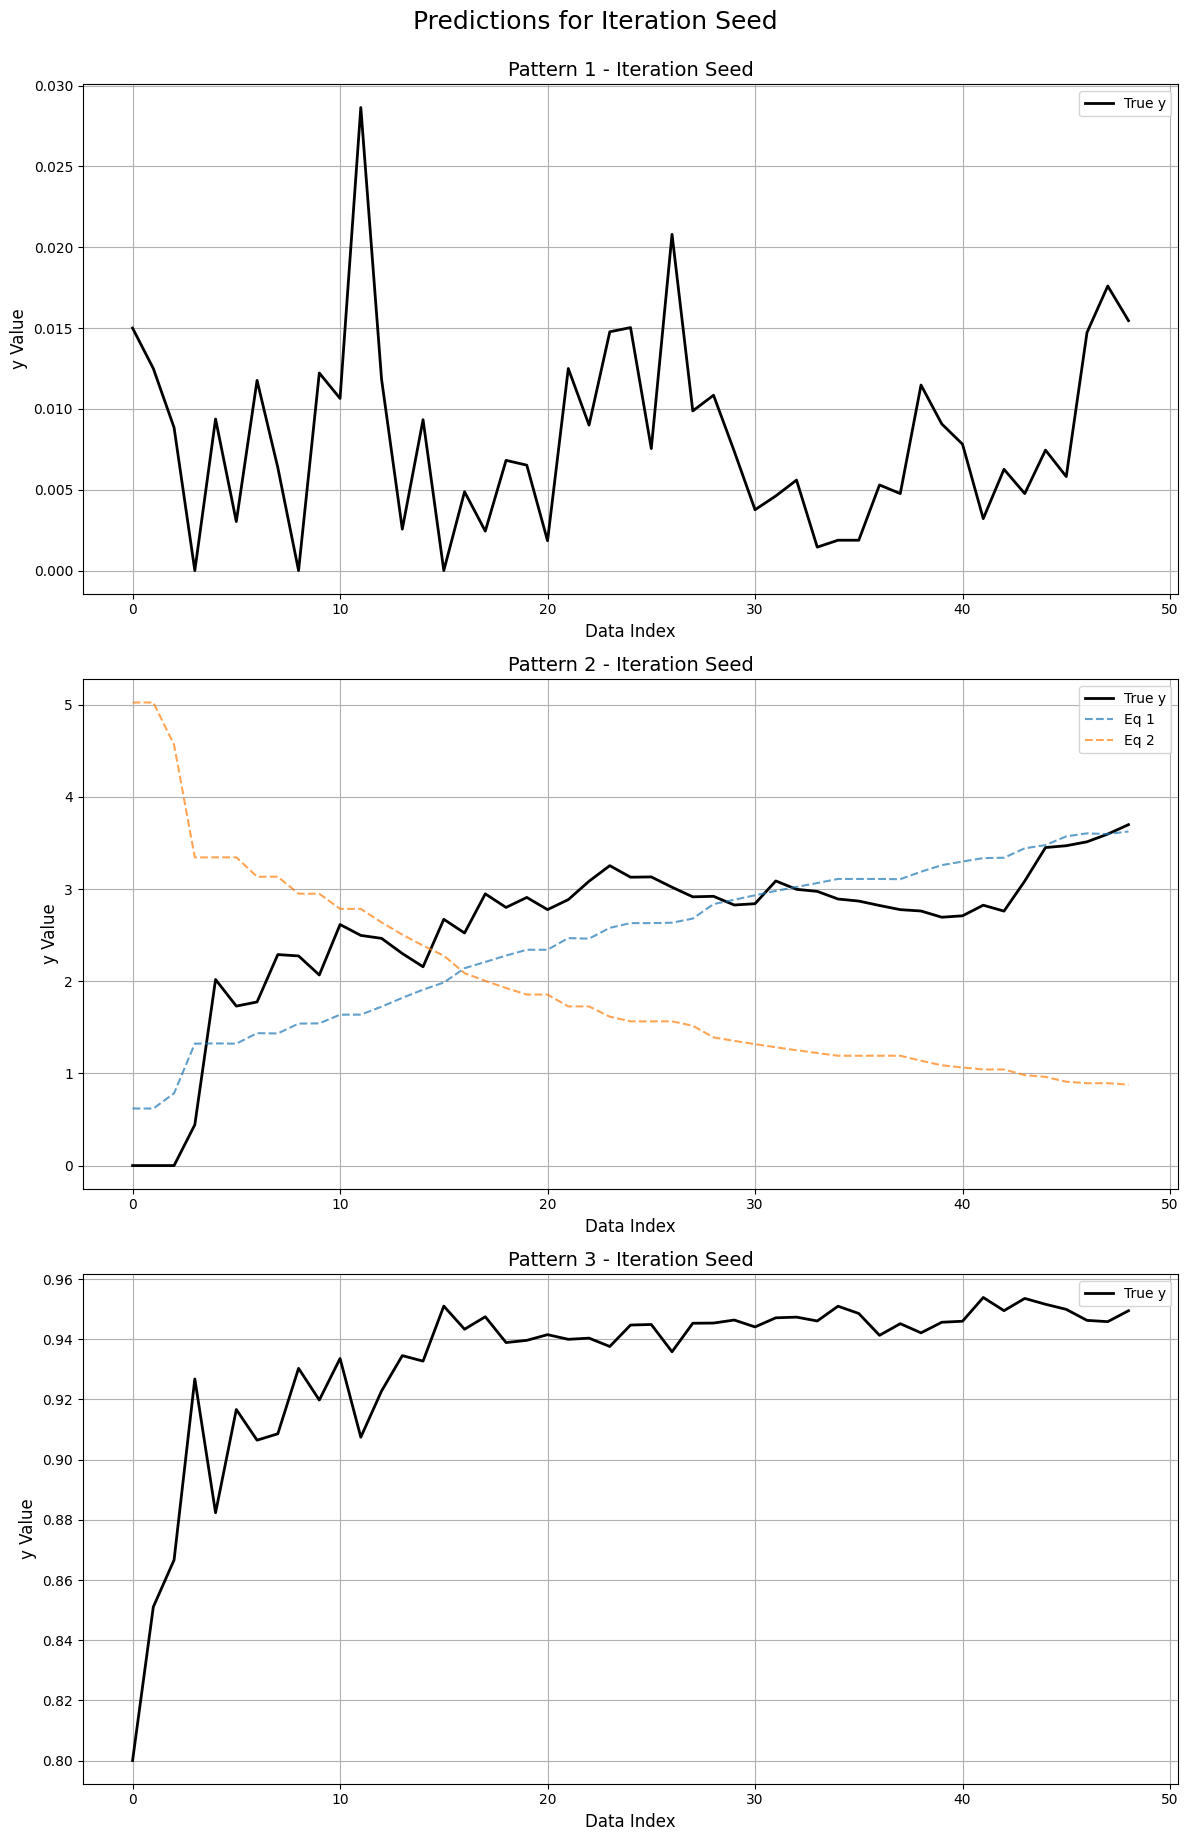

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1:
- Analyze the relationship between current indicators and next-slot compute load.
- Consider polynomial terms, exponential/log transformations, and cross-variable interactions.
- Moving averages, residual dynamics, and state memory are critical for temporal modeling.

Potential expressions:
1. y = x1^2 + x2 * x3 - movavg(x4, 3)
2. y = x2^3 / log(1 + x3) + x4 - x5
3. y = x1 * x3 + exp(x3) - x5

Pattern 2:
- Predict V2U rate considering vehicle density, UAV density, and compute load.
- Use saturating growth forms and resource competition effects.
- Avoid strict output bounding; focus on realistic floating range.

Potential expressions:
1. y = x2 / (1 + x1) + x3^2 / (x1 + 1)
2. y = log(1 + x1) * x2 / (x3 + c0)
3. y = (x2 - x3)^2 - x1 * x3

Pattern 3:
- Predict task success ratio using current V2U rate, V2I rate, and compute load.
- Sigmoid-like structures, load penalty, bandwidth interplay, 

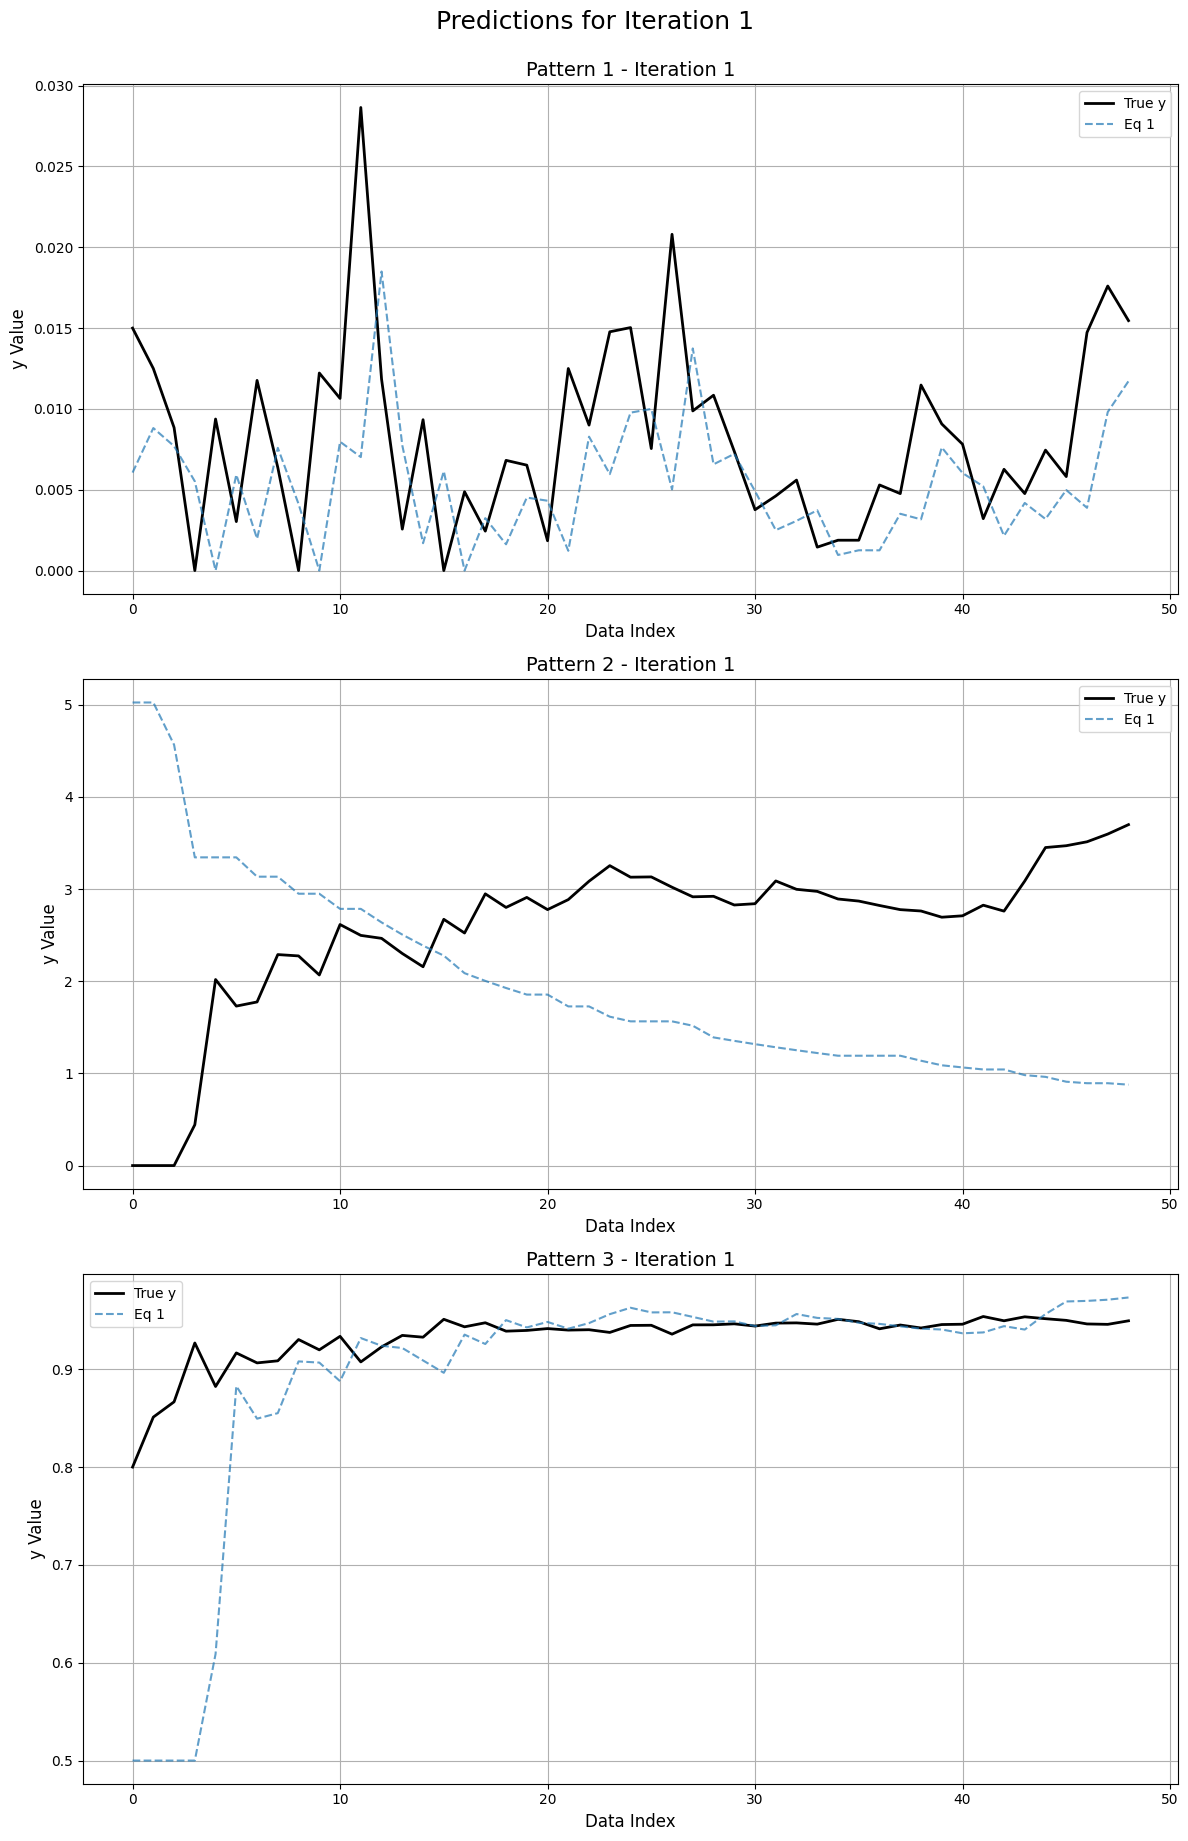

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'log(x1+1)*x4', 'complexity': 6, 'nmae': np.float64(0.16911522926167874), 'fitted_params': []}], [{'equation': 'log(1+x1)*x2/(x3+c[0])', 'complexity': 10, 'nmae': np.float64(0.11744198631584739), 'fitted_params': [4.156205258116311]}, {'equation': 'x2/(1+x1)+x3**2/(x1+1)', 'complexity': 13, 'nmae': np.float64(0.4421975984779885), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
First, let's analyze the dataset and the requirements for each pattern:

Pattern 1:
- Predict average compute load at the next time slot.
- Consider polynomial terms, exponential/logarithmic transformations, cross-variable interactions, and temporal modeling elements.
- Include structures such as moving average, residual dynamics, and state memo

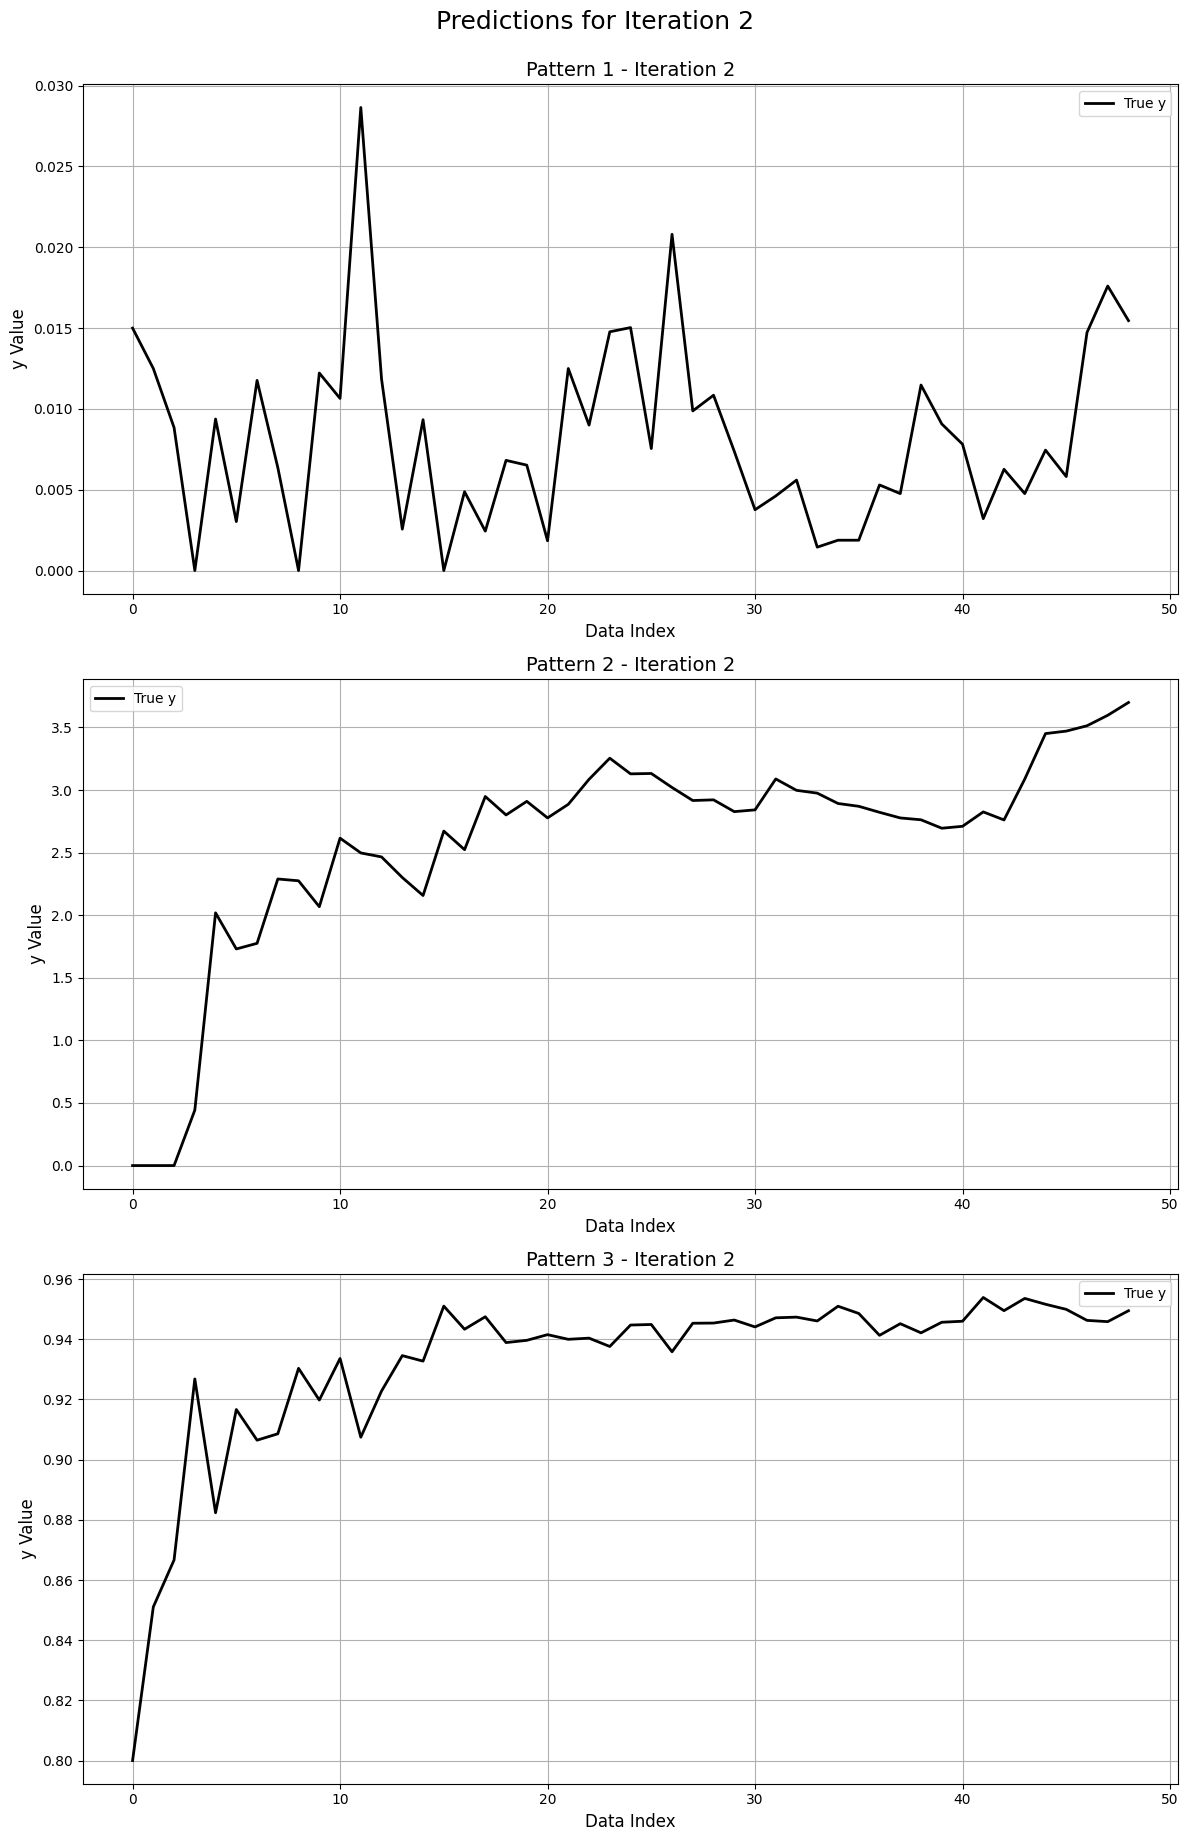

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'log(x1+1)*x4', 'complexity': 6, 'nmae': np.float64(0.16911522926167874), 'fitted_params': []}], [{'equation': 'log(1+x1)*x2/(x3+c[0])', 'complexity': 10, 'nmae': np.float64(0.11744198631584739), 'fitted_params': [4.156205258116311]}, {'equation': 'x2/(1+x1)+x3**2/(x1+1)', 'complexity': 13, 'nmae': np.float64(0.4421975984779885), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
First, let's analyze the dataset and previous equations to propose new expressions for each pattern.

Pattern 1 involves predicting the average compute load at the next time slot using indicators like task success ratio, vehicle density, V2U density, and compute loads at current and previous time slots. We should consider polynomial terms, expon

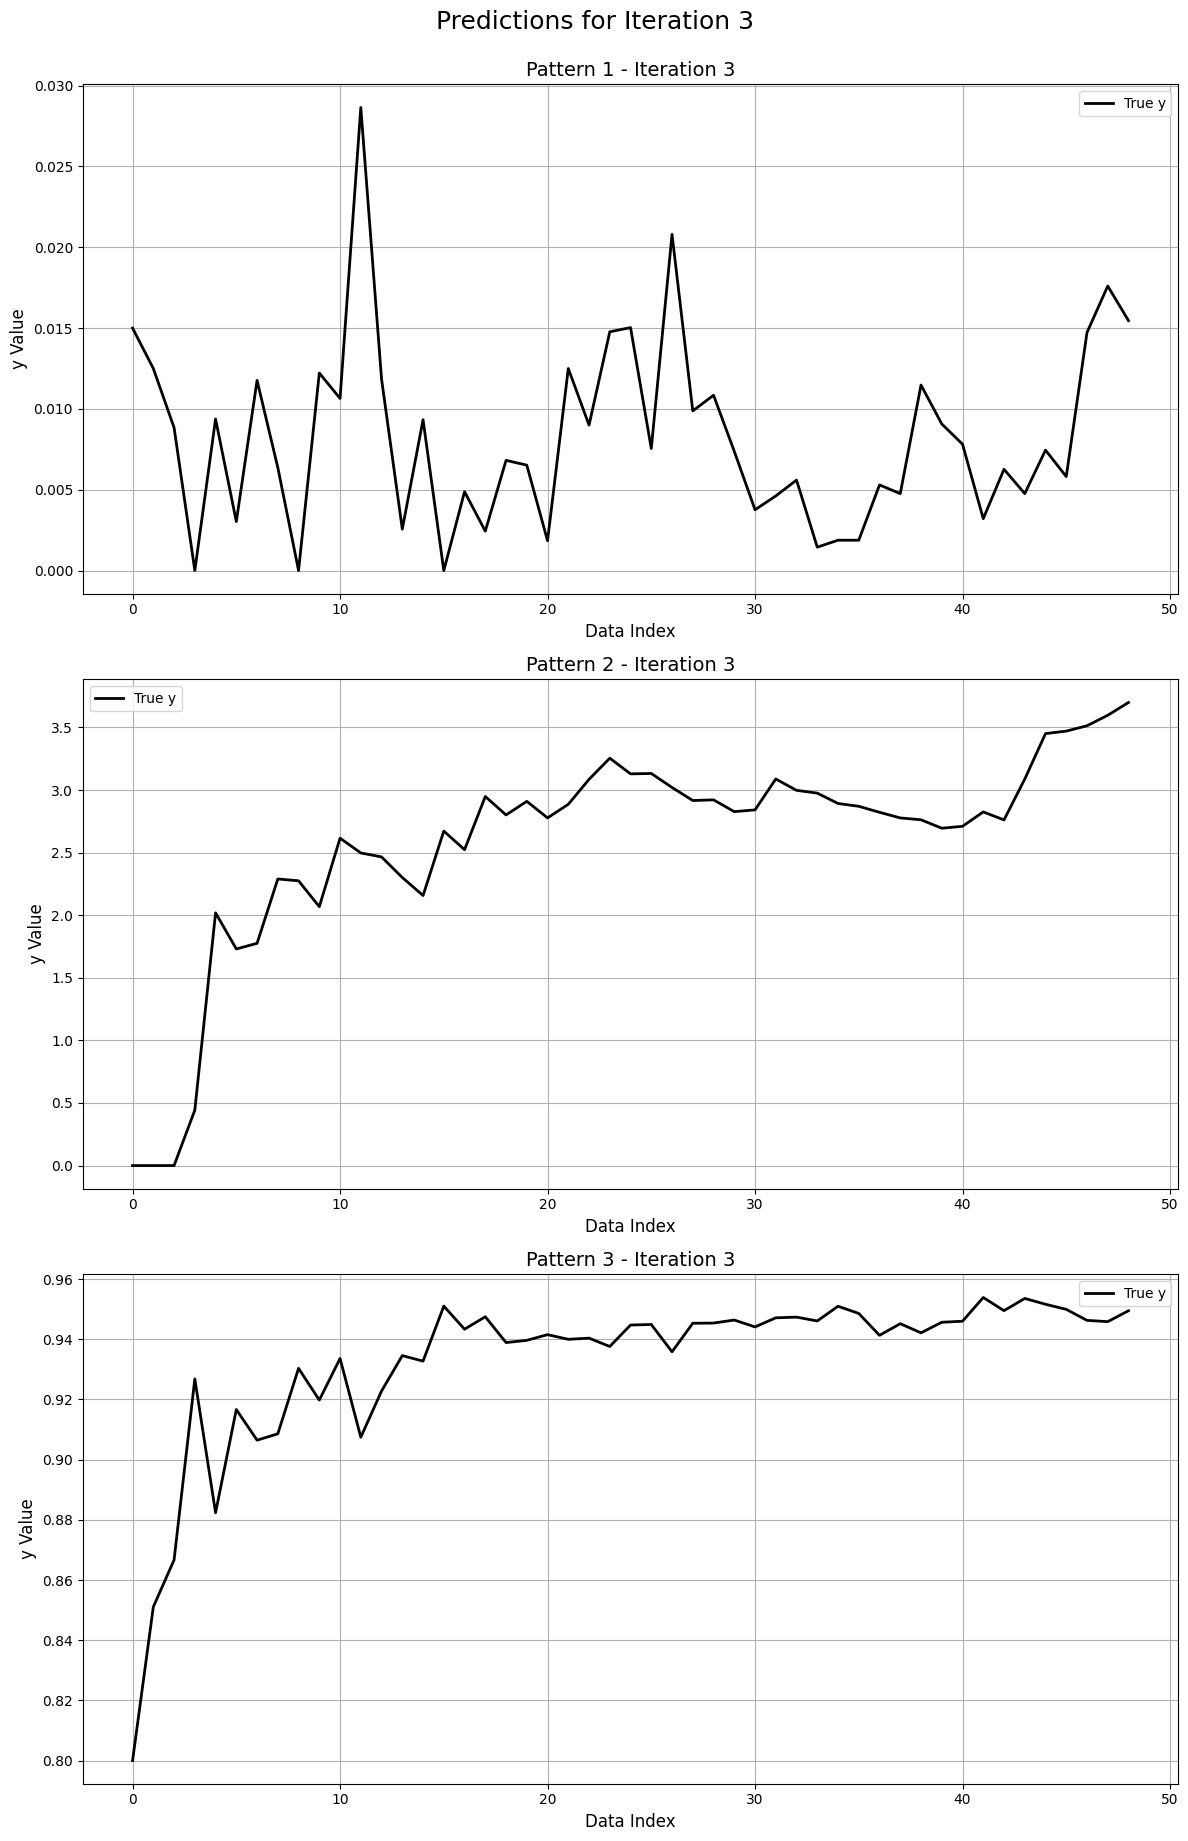

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'log(x1+1)*x4', 'complexity': 6, 'nmae': np.float64(0.16911522926167874), 'fitted_params': []}], [{'equation': 'log(1+x1)*x2/(x3+c[0])', 'complexity': 10, 'nmae': np.float64(0.11744198631584739), 'fitted_params': [4.156205258116311]}, {'equation': 'x2/(1+x1)+x3**2/(x1+1)', 'complexity': 13, 'nmae': np.float64(0.4421975984779885), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
Scratch Pad:

1. **Pattern 1: Predicting Compute Load**
   - The dependent variable (y) is influenced by the current task success ratio, vehicle density, average V2U density, current average compute load, and previous average compute load.
   - Suggested structures include polynomial terms, exponential/logarithmic transformations, cross-variable

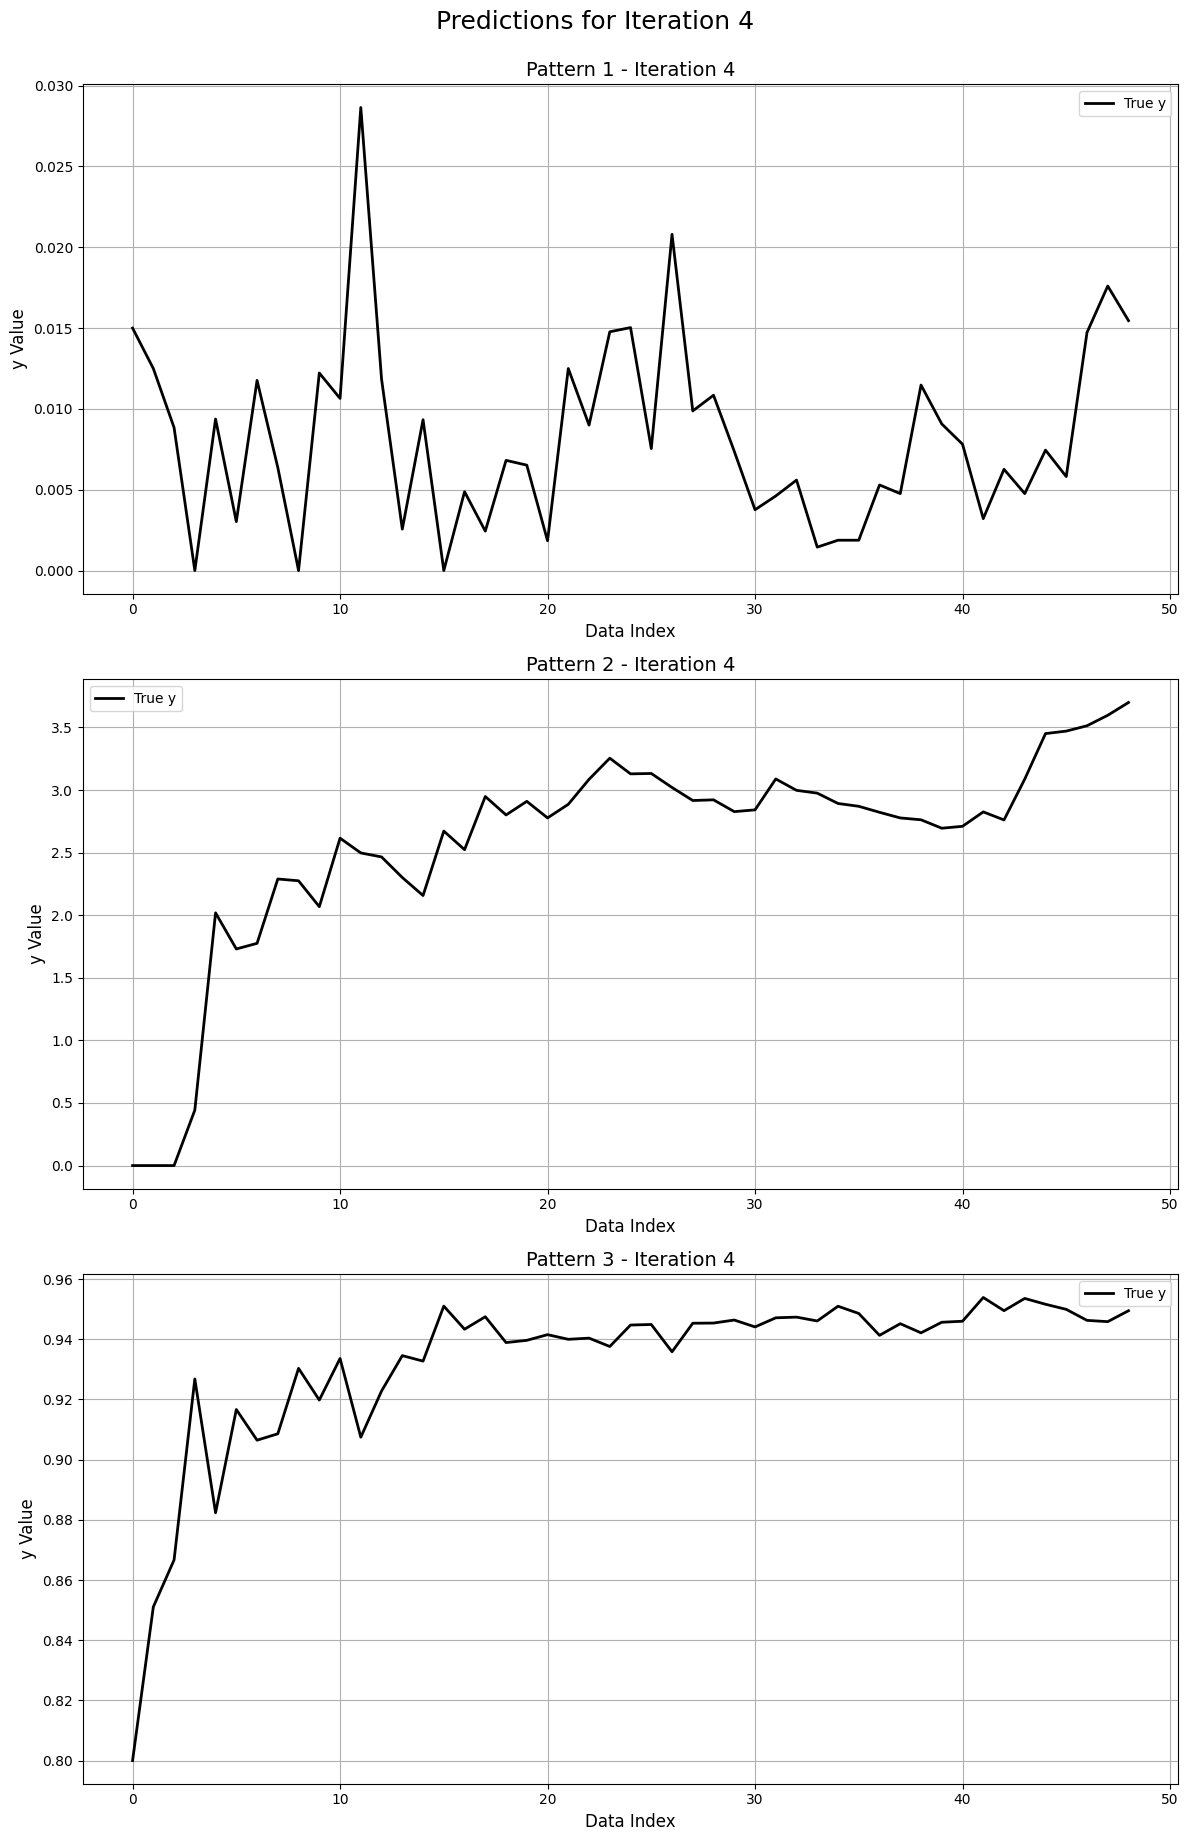

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'log(x1+1)*x4', 'complexity': 6, 'nmae': np.float64(0.16911522926167874), 'fitted_params': []}], [{'equation': 'log(1+x1)*x2/(x3+c[0])', 'complexity': 10, 'nmae': np.float64(0.11744198631584739), 'fitted_params': [4.156205258116311]}, {'equation': 'x2/(1+x1)+x3**2/(x1+1)', 'complexity': 13, 'nmae': np.float64(0.4421975984779885), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
The dataset involves three predictive patterns for a low-altitude vehicular network. Each pattern uses different independent variables to predict specific dependent variables. The goal is to minimize both complexity and loss in the suggested equations, with a focus on diverse functional forms.

1. **Pattern 1**: Predicting the average compute lo

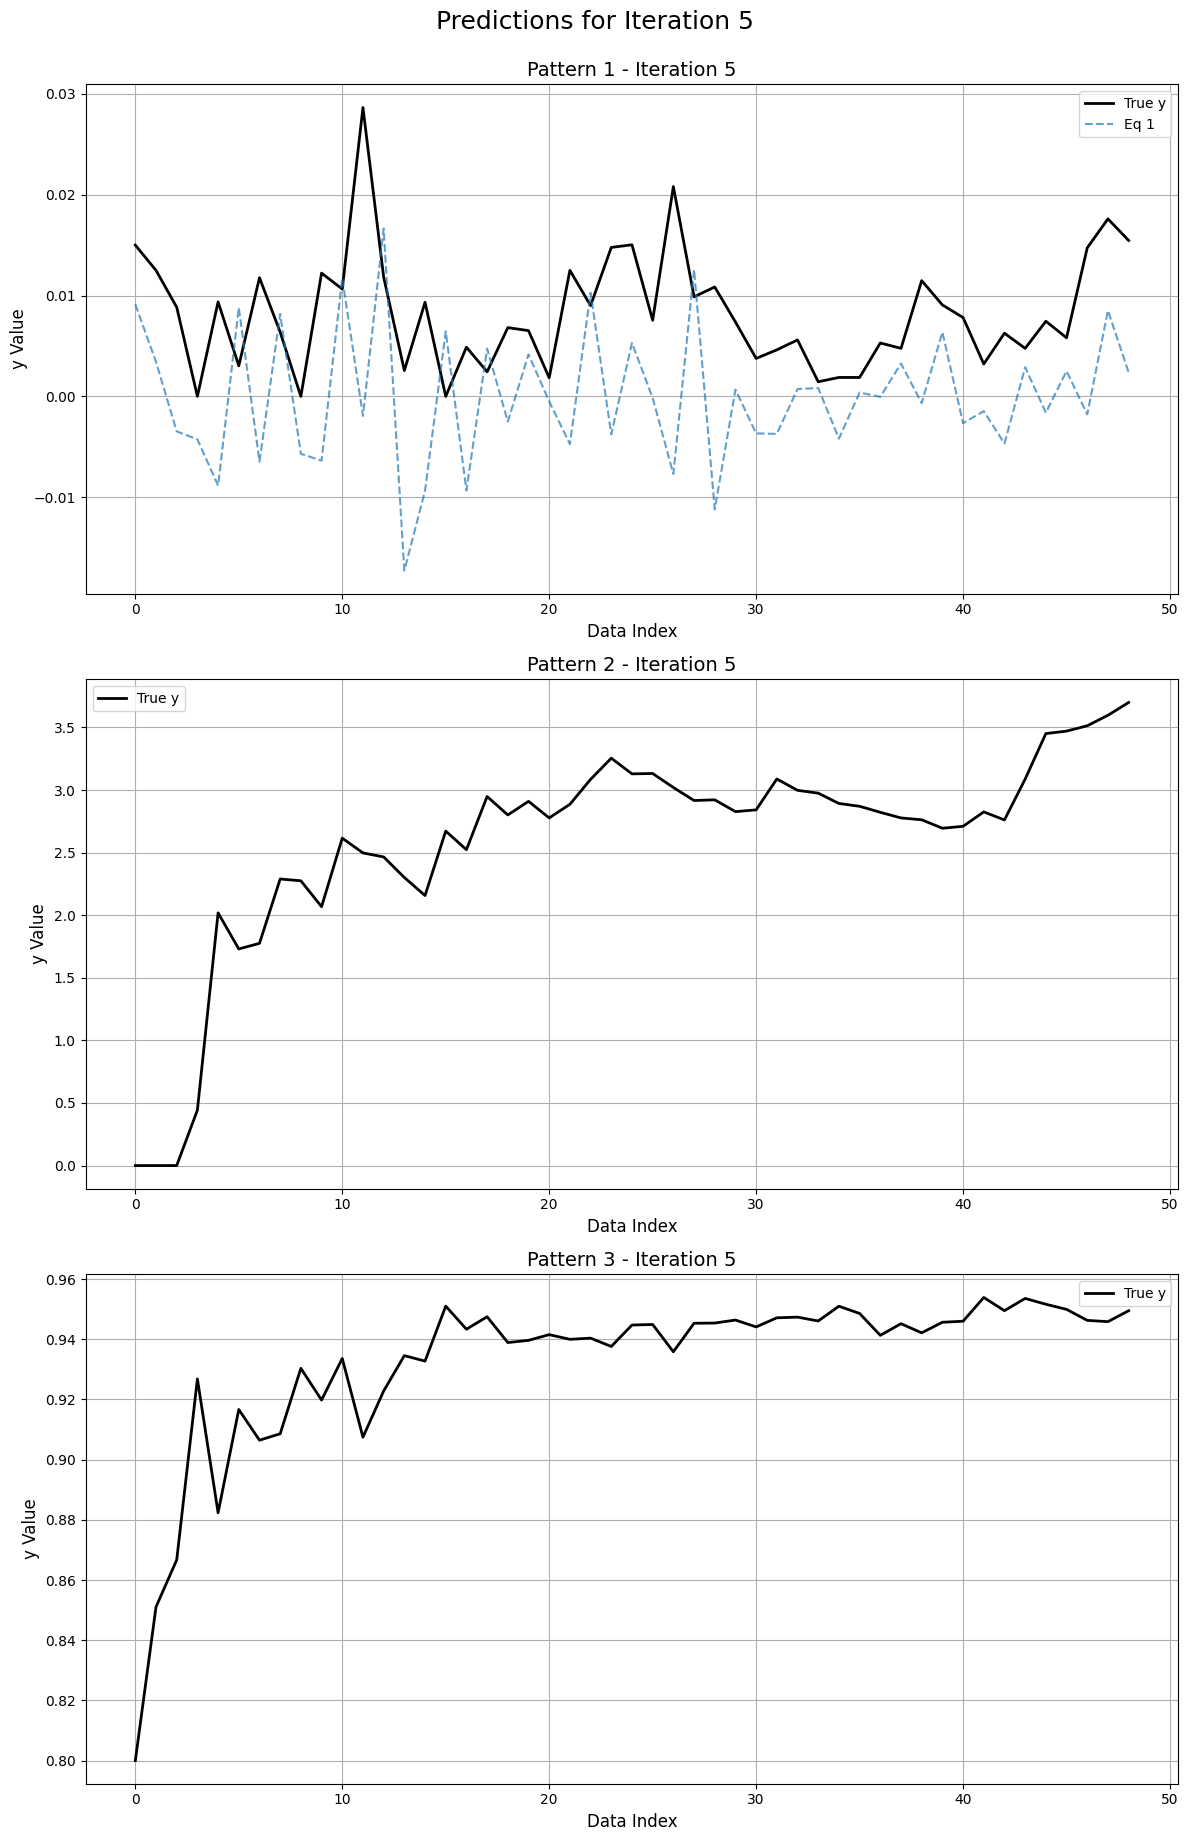

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'log(x1+1)*x4', 'complexity': 6, 'nmae': np.float64(0.16911522926167874), 'fitted_params': []}, {'equation': 'sqrt(x1)*x4-x5', 'complexity': 6, 'nmae': np.float64(0.3246784454289787), 'fitted_params': []}], [{'equation': 'log(1+x1)*x2/(x3+c[0])', 'complexity': 10, 'nmae': np.float64(0.11744198631584739), 'fitted_params': [4.156205258116311]}, {'equation': 'x2/(1+x1)+x3**2/(x1+1)', 'complexity': 13, 'nmae': np.float64(0.4421975984779885), 'fitted_params': []}, {'equation': 'x2/(1+x1)', 'complexity': 5, 'nmae': np.float64(0.4421952620809291), 'fitted_params': []}], [{'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts:
The data provided consists of 3 distinct patterns, each with a dependent variable to predict based on multiple independent variables. Here is the analysis:

**Pattern 1: Predicting Average Compute Load at Next Time Slot**
- **Independent

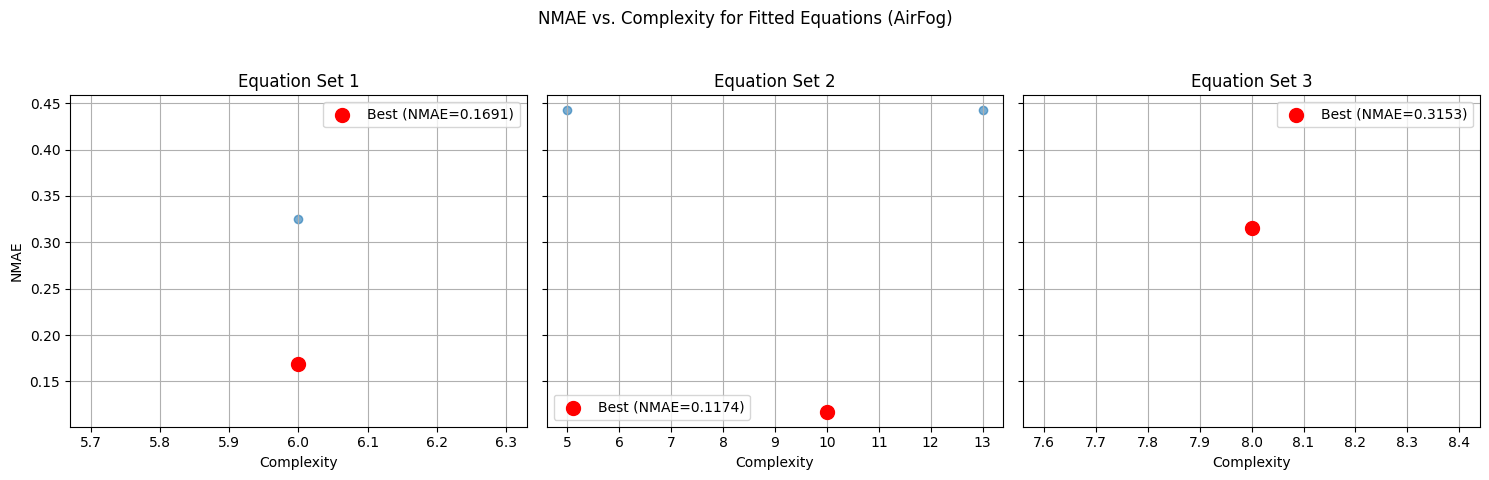

Experiment 2 finished.
Running experiment 3...


PermissionDeniedError: Error code: 403 - {'error': {'message': '账户余额过低不足以支持本次请求，请前往 https://api.chatanywhere.tech/#/shop 充值。Your account balance is not sufficient to support this request. Please visit https://api.chatanywhere.tech/#/shop to recharge.(当前请求使用的ApiKey: sk-5T6****HpIy)', 'type': 'chatanywhere_error', 'param': None, 'code': '403 FORBIDDEN'}}

In [8]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_ord_output = '[["x_{4} + c_{0}(x_{4} - x_{5})","x_{4}(c_{0} + x_{1})","c_{0}\\\\,\\\\mathrm{movavg}(x_{1},3) + c_{1}x_{5}"],["\\\\min\\\\bigl(c_{0},\\\\frac{x_{2}}{x_{1} + c_{1}}\\\\bigr)","\\\\frac{x_{1}x_{2}}{c_{0} + x_{3}}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-c_{0}(x_{2}/x_{1})\\\\bigr)}"],["\\\\frac{1}{1 + \\\\exp\\\\bigl(-c_{0}(x_{1}x_{2})\\\\bigr)}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-(x_{1} - c_{0}x_{3})\\\\bigr)}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-\\\\bigl(c_{0}x_{1} + c_{1}x_{2} - c_{2}x_{3}\\\\bigr)\\\\bigr)}"]]'
llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_ord_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


Parsed Row:
['x4 + c[0](x4 - x5)', 'x4(c[0] + x1)', 'c[0]\\,\\mathrm{movavg}(x1,3) + c[1]x5']
Formatted Row:
['x4+c[0]*(x4-x5)', 'x4*(c[0]+x1)', 'c[0]*movavg(1, 3)+c[1]*x5']


Parsed Row:
['\\min\\bigl(c[0],\\frac{x2}{x1 + c[1]}\\bigr)', '\\frac{x1x2}{c[0] + x3}', '\\frac{1}{1 + \\exp\\bigl(-c[0](x2/x1)\\bigr)}']
Formatted Row:
['min(c[0],(x2)/(x1+c[1]))', '(x1*x2)/(c[0]+x3)', '(1)/(1+exp(-c[0]*(x2/x1)))']


Parsed Row:
['\\frac{1}{1 + \\exp\\bigl(-c[0](x1x2)\\bigr)}', '\\frac{1}{1 + \\exp\\bigl(-(x1 - c[0]x3)\\bigr)}', '\\frac{1}{1 + \\exp\\bigl(-\\bigl(c[0]x1 + c[1]x2 - c[2]x3\\bigr)\\bigr)}']
Formatted Row:
['(1)/(1+exp(-c[0]*(x1*x2)))', '(1)/(1+exp(-(x1-c[0]*x3)))', '(1)/(1+exp(-(c[0]*x1+c[1]*x2-c[2]*x3)))']




In [1]:
from helper import format_and_parse_expressions, format_expressions
test_inputs = "['\\min\\bigl(1, \\max(0, c_0 x_1 + c_1 \\frac{x_2}{x_3})\\bigr)', 'c_0 x_1^2 + c_1 \\log(x_2 + 1) + c_2 \\sqrt{x_3}', 'cube_root(x1 + x2)', 'square(x3)', 'movavg(x1, 3)', 'c_1 x y + z']"
results = format_expressions(format_and_parse_expressions(test_inputs))
for i, (inp, outp) in enumerate(zip(test_inputs, results)):
    print(f"{i+1}. {outp}")

1. min(1,max(0,c[0]*x1+c[1]*(x2)/(x3)))
2. c[0]*x1**2+c[1]*log(x2+1)+c[2]*(x3)**0.5
3. x1+x2**(1/3)
4. x3**2
5. movavg(1, 3)
6. c[1]*x1*x2+x3
